# Experimental Evaluation

In [1]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

font = {
        'size'   : 11}
mpl.rc('font', **font)

In [2]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


In [4]:
def set_square_size(width_pt, fraction=1):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    return (fig_width_in, fig_width_in)


# An example CSV

In [5]:
csv1 =  pd.read_csv("CSV/example-1.csv").rename(columns={'output': 'verdict_example_1', 'time': 'time_example_1'})
csv1

,instance,verdict_example_1,time_example_1
0,dreal-conv/flyspeck/557.smt2,timeout,1000.00
1,dreal-conv/tests/kinematic_arm_1DOF_4.smt2,unsat,0.02
2,dreal-conv/flyspeck/882.smt2,timeout,1000.00
3,metitarski/sin-problem-10-2.smt2,timeout,1000.00
4,metitarski/sin-344-4.smt2,timeout,1000.00
...,...,...,...
2507,metitarski/trigpoly-3510-5.smt2,unsat,1.10
2508,bmc/nav_17.transcendental.k2.smt2,unsat,0.02
2509,bmc/heater_13.transcendental.k1.smt2,unsat,0.03
2510,bmc/unstable_unit_circle2.transcendental.k3.smt2,timeout,1000.00


In [6]:
print("Number of instances:", csv1.shape[0])
print("SAT:", csv1.query("verdict_example_1 == 'sat'").shape[0])
print("UNSAT:", csv1.query("verdict_example_1 == 'unsat'").shape[0])
print("SAT or UNSAT:", csv1.query("verdict_example_1 == 'sat' or verdict_example_1 == 'unsat'").shape[0])
print("UNKNOWN:", csv1.query("verdict_example_1 == 'unknown'").shape[0])
print("TIMEOUT:", csv1.query("verdict_example_1 == 'timeout'").shape[0])
count_errors = csv1[csv1["verdict_example_1"].str.contains("error:", na=False)].shape[0]
print("ERROR:", count_errors)

Number of instances: 2512
SAT: 101
UNSAT: 954
SAT or UNSAT: 1055
UNKNOWN: 0
TIMEOUT: 1123
ERROR: 99


# A second CSV

In [7]:
csv2 =  pd.read_csv("CSV/example-2.csv").rename(columns={'output': 'verdict_example_2', 'time': 'time_example_2'})
csv2

,instance,verdict_example_2,time_example_2
0,dreal-conv/flyspeck/348.smt2,timeout,1000.00
1,bmc/freezer.k10.smt2,unsat,16.00
2,bmc/WBS_blue_faulty_arch4_02_p1.transcendental...,unsat,0.09
3,dreal-conv/flyspeck/453.smt2,timeout,1000.00
4,metitarski/Nichols-Plot-Inverted-Pendulum-Fail...,unsat,0.00
...,...,...,...
2484,bmc/forsman_phd_ex_6_1_page_99.transcendental....,timeout,1000.00
2485,dreal-conv/powersystems/dreal_file_3_5.smt2,timeout,1000.00
2486,metitarski/Nichols-Plot-Inverted-Pendulum-Fail...,timeout,1000.00
2487,bmc/dumortier_llibre_artes_ex_1_9a.transcenden...,timeout,1000.00


In [8]:
print("Number of instances:", csv2.shape[0])
print("SAT:", csv2.query("verdict_example_2 == 'sat'").shape[0])
print("UNSAT:", csv2.query("verdict_example_2 == 'unsat'").shape[0])
print("SAT or UNSAT:", csv2.query("verdict_example_2 == 'sat' or verdict_example_2 == 'unsat'").shape[0])
print("UNKNOWN:", csv2.query("verdict_example_2 == 'unknown'").shape[0])
print("TIMEOUT:", csv2.query("verdict_example_2 == 'timeout'").shape[0])
count_errors = csv2[csv2["verdict_example_2"].str.contains("error:", na=False)].shape[0]
print("ERROR:", count_errors)

Number of instances: 2489
SAT: 44
UNSAT: 918
SAT or UNSAT: 962
UNKNOWN: 0
TIMEOUT: 1527
ERROR: 0


# Combine the CSVs

In [9]:
all_csvs = csv1
all_csvs = csv2.join(all_csvs.set_index("instance"), on="instance", how="left")
all_csvs


,instance,verdict_example_2,time_example_2,verdict_example_1,time_example_1
0,dreal-conv/flyspeck/348.smt2,timeout,1000.00,timeout,1000.00
1,bmc/freezer.k10.smt2,unsat,16.00,timeout,1000.00
2,bmc/WBS_blue_faulty_arch4_02_p1.transcendental...,unsat,0.09,unsat,0.14
3,dreal-conv/flyspeck/453.smt2,timeout,1000.00,timeout,1000.00
4,metitarski/Nichols-Plot-Inverted-Pendulum-Fail...,unsat,0.00,unsat,0.01
...,...,...,...,...,...
2484,bmc/forsman_phd_ex_6_1_page_99.transcendental....,timeout,1000.00,timeout,1000.00
2485,dreal-conv/powersystems/dreal_file_3_5.smt2,timeout,1000.00,error: yices_smt2: /build/libpoly0-udZsPE/libp...,0.05
2486,metitarski/Nichols-Plot-Inverted-Pendulum-Fail...,timeout,1000.00,timeout,1000.00
2487,bmc/dumortier_llibre_artes_ex_1_9a.transcenden...,timeout,1000.00,timeout,1000.00


# Plots

In [10]:
# Times below 0.1s taken as 0.1s for better visualization
min_time = 0.1
for col in ["time_example_1", "time_example_2"]:
    all_csvs.loc[all_csvs[col] <= min_time, col] = min_time

# Find max time for better visualization
max_time = all_csvs[["time_example_1", "time_example_2"]].max().max()

solvers = ['example_1', 'example_2']

labels = {
    "example_1" : "Ex 1",
    "example_2" : "Ex 2",
}

colors = {
    "example_1"  : "blue",
    "example_2"  : "orange",
}


### Survival plotter

In [11]:

def plot_survival(solvers, verdict_types, y_label):
    solver_times_sorted = {}
    solver_cumulative_sol = {}
    solver_plot = {}
    
    plt.figure(figsize=(8,6))
    
    for solver in solvers:
        verdict_col = f'verdict_{solver}'
        time_col = f'time_{solver}'
        
        times = all_csvs.loc[all_csvs[verdict_col].isin(verdict_types), time_col]
        times = pd.to_numeric(times, errors='coerce').dropna()
    
        solver_times_sorted[solver] = np.sort(times)
        solver_cumulative_sol[solver] = np.arange(1, len(solver_times_sorted[solver])+1)
    
        solver_plot[solver] = np.clip(solver_times_sorted[solver], min_time, None)
        solver_plot[solver] = np.append(solver_plot[solver], max_time)
        solver_cumulative_sol[solver] = np.append(solver_cumulative_sol[solver], solver_cumulative_sol[solver][-1])
    
        plt.step(solver_plot[solver], solver_cumulative_sol[solver], where='post', color = colors[solver], label=labels[solver])
    
    plt.xlabel('Time (seconds)')
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, which='both')
    
    plt.xscale('log', base=10)
    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    plt.xticks([min_time*(10**i) for i in range(int(np.log10(max_time))+2)])
    
    plt.show()


### Survival Plot of sat + unsat

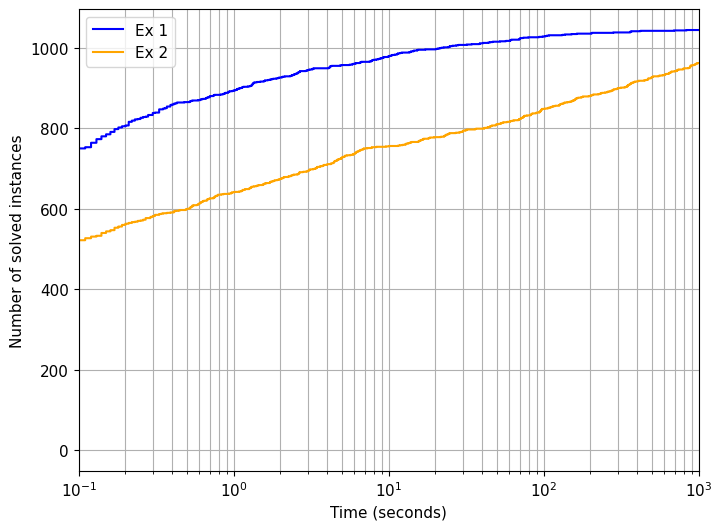

In [12]:
verdict_types = ['sat','unsat']

plot_survival(solvers, verdict_types, 'Number of solved instances')

### Survival plot of sat only

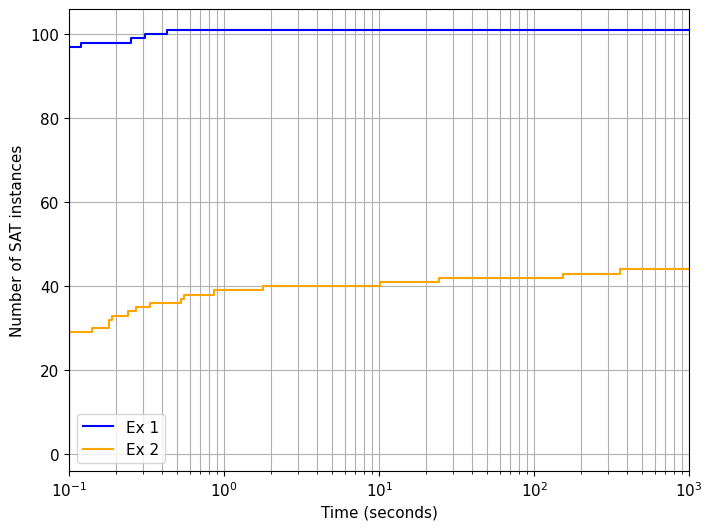

In [13]:
verdict_types = ['sat']

plot_survival(solvers, verdict_types, 'Number of SAT instances')

### Survival plot of unsat only

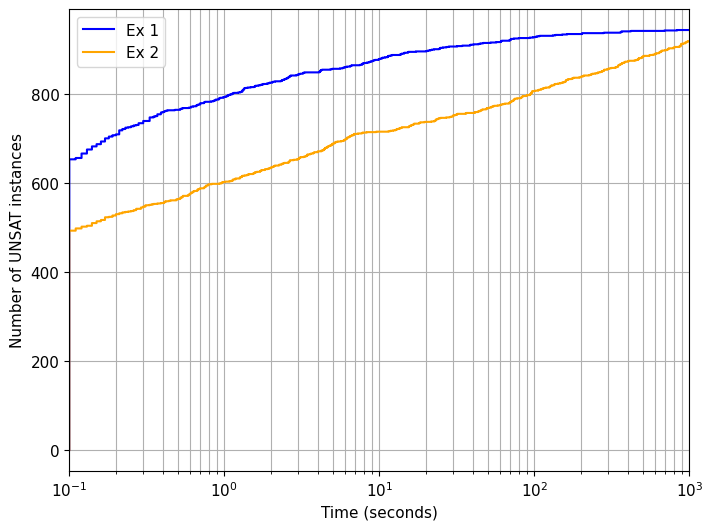

In [14]:
verdict_types = ['unsat']

plot_survival(solvers, verdict_types, 'Number of UNSAT instances')